In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/Sentiment/IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
df.sentiment = df.sentiment.replace('positive',1).replace('negative',0)

In [4]:
import numpy as np

print('Max length: ', max(df.review.str.len()))
print('Min length: ', min(df.review.str.len()))

Max length:  13704
Min length:  32


In [5]:
import nltk
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
stop_words = stopwords.words("english")
stemmer = SnowballStemmer("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [6]:
from bs4 import BeautifulSoup
import re

for sentence in range(0, len(df.review)):
  # xóa tag, link http
  processed_feature = BeautifulSoup(str(df.review[sentence]), "html.parser").get_text()
  #email-id
  processed_feature = re.sub('b[w-]+?@w+?.w{2,4}b', 'emailadd', processed_feature)
  #url
  processed_feature = re.sub('(http[s]?S+)|(w+.[A-Za-z]{2,4}S*)', 'urladd', processed_feature)

  # Xóa tất cả các ký tự đặc biệt
  processed_feature = re.sub(r'\W', ' ', processed_feature)

  # xóa tất cả các ký tự đơn
  processed_feature = re.sub(r'\s+[a-zA-Z]\s+', ' ', processed_feature)
  processed_feature = re.sub(r'\^[a-zA-Z]\s+', ' ', processed_feature)

  # Chuyển đổi sang chữ thường
  processed_feature = processed_feature.lower()

  # xóa stopwords
  processed_feature = " ".join([word for word in str(processed_feature).split() if word not in stop_words])

  # trả về nguyên mẫu
  # processed_feature = " ".join([stemmer.stem(word) for word in str(processed_feature).split()])

  # Thay thế nhiều khoảng trắng bằng một khoảng trắng
  processed_feature = re.sub(r'\s+', ' ', processed_feature, flags=re.I)

  # processed_features.append(processed_feature)
  df.review[sentence] = processed_feature

<ipython-input-6-d813c73187bd>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.review[sentence] = processed_feature
<ipython-input-6-d813c73187bd>:6: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  processed_feature = BeautifulSoup(str(df.review[sentence]), "html.parser").get_text()


In [7]:
print('Max length: ', max(df.review.str.len()))
print('Min length: ', min(df.review.str.len()))

Max length:  9616
Min length:  22


In [8]:
X_train, X_test, y_train, y_test = train_test_split(df.review, df.sentiment, test_size=.2, random_state=42)

In [9]:
import gensim

documents = [_text.split() for _text in X_train]
w2v_model = gensim.models.word2vec.Word2Vec(vector_size=300,
                                            window=7,
                                            min_count=10,
                                            workers=8)

w2v_model.build_vocab(documents)

w2v_model.train(documents, total_examples=len(documents), epochs=16)

(69213563, 79064560)

In [10]:
w2v_model.wv.most_similar("hate")

[('hated', 0.5006951093673706),
 ('despise', 0.4735313951969147),
 ('dislike', 0.4479213058948517),
 ('sucks', 0.40673157572746277),
 ('suck', 0.384717732667923),
 ('loathe', 0.3813624680042267),
 ('like', 0.3559483587741852),
 ('think', 0.35208749771118164),
 ('either', 0.35060375928878784),
 ('understand', 0.3501769006252289)]

In [11]:
words = w2v_model.wv
vocab_size = len(words)
print("Vocab size", vocab_size)

Vocab size 24973


In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print("Total words", vocab_size)

Total words 98476


In [14]:
embedding_matrix = np.zeros((vocab_size, 300))
for word, i in tokenizer.word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i] = w2v_model.wv[word]
print(embedding_matrix.shape)

(98476, 300)


In [15]:
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=300)
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=300)

In [16]:
print("x_train", X_train.shape)
print("y_train", y_train.shape)
print()
print("x_test", X_test.shape)
print("y_test", y_test.shape)

x_train (40000, 300)
y_train (40000,)

x_test (10000, 300)
y_test (10000,)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D, Layer, MultiHeadAttention
from tensorflow.keras.layers import LayerNormalization, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, rate=0.25):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads,
                                      key_dim=embed_dim)
        self.ffn = Sequential([
            Conv1D(128, 3, padding='same'),

            Dense(128, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)  # self-attention layer
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # layer norm
        ffn_output = self.ffn(out1)  #feed-forward layer
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)  # layer norm


class TokenAndPositionEmbedding(Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size,
                                   output_dim=embed_dim)
        self.pos_emb = Embedding(input_dim=maxlen + 1,  # vocab size, including the 0-th word used for padding
                       output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [26]:
embed_dim = 128  # Embedding size for each token
num_heads = 3  # Number of attention heads
maxlen = 300

model = Sequential()
model.add(Input(shape=(maxlen, )))
model.add(TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim))
model.add(Conv1D(128,7))
model.add(TransformerBlock(embed_dim, num_heads))
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer="adam",
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 token_and_position_embeddi  (None, 300, 128)          12643456  
 ng_2 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 conv1d_3 (Conv1D)           (None, 294, 128)          114816    
                                                                 
 transformer_block_2 (Trans  (None, 294, 128)          280704    
 formerBlock)                                                    
                                                                 
 global_average_pooling1d_2  (None, 128)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dropout_10 (Dropout)        (None, 128)              

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=3)

history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1,
                    callbacks= callbacks)

Epoch 1/100
36/36 [==============================] - 36s 839ms/step - loss: 0.7063 - accuracy: 0.5408 - val_loss: 0.5587 - val_accuracy: 0.8005
Epoch 2/100
36/36 [==============================] - 28s 788ms/step - loss: 0.4080 - accuracy: 0.8223 - val_loss: 0.3026 - val_accuracy: 0.8798
Epoch 3/100
36/36 [==============================] - 27s 759ms/step - loss: 0.1758 - accuracy: 0.9359 - val_loss: 0.2781 - val_accuracy: 0.8920
Epoch 4/100
36/36 [==============================] - 28s 770ms/step - loss: 0.0901 - accuracy: 0.9714 - val_loss: 0.4448 - val_accuracy: 0.8760
Epoch 5/100
36/36 [==============================] - 28s 776ms/step - loss: 0.0532 - accuracy: 0.9836 - val_loss: 0.4821 - val_accuracy: 0.8792
Epoch 6/100
36/36 [==============================] - 28s 770ms/step - loss: 0.0275 - accuracy: 0.9916 - val_loss: 0.5973 - val_accuracy: 0.8810


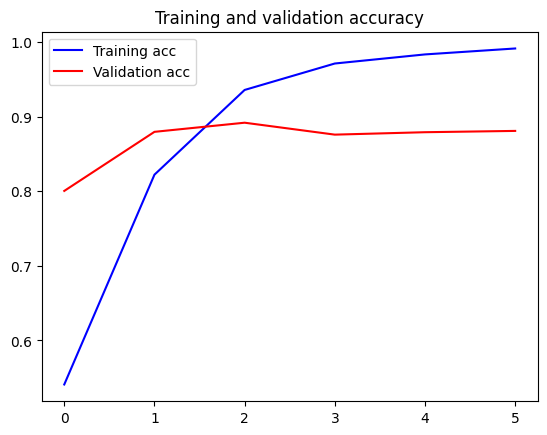

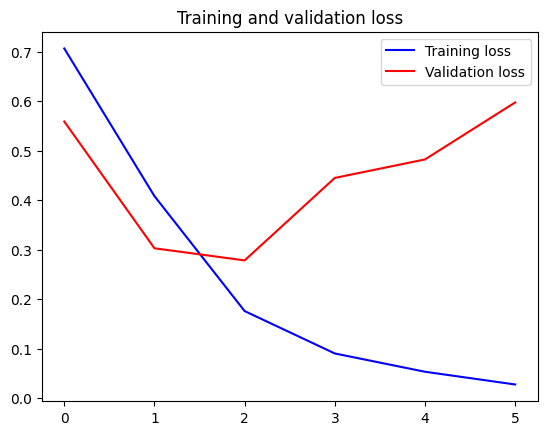

In [28]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [29]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

10/10 [==============================] - 3s 298ms/step - loss: 0.6322 - accuracy: 0.8739

ACCURACY: 0.8738999962806702
LOSS: 0.6322128772735596
